In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("train.csv.zip",encoding=('ISO-8859-1'),low_memory=False)
df.head()

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,...,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability
0,0,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,31.277,87.009,...,0,0,NaN,NaN,NaN,1958,0.0,0.0,0.0,0
1,1,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,0.000,122.787,...,0,0,NaN,1.0,NaN,710,0.0,0.0,0.0,0
2,2,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,60.806,103.176,...,0,0,NaN,NaN,NaN,882,0.0,0.0,0.0,0
3,3,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,156.362,205.260,...,0,0,NaN,NaN,NaN,982,0.0,0.0,0.0,0
4,4,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,240.708,128.191,...,1,0,1.0,1.0,1.0,647,0.0,0.0,0.0,0


In [3]:
df.shape

(69999, 172)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69999 entries, 0 to 69998
Columns: 172 entries, id to churn_probability
dtypes: float64(135), int64(28), object(9)
memory usage: 91.9+ MB


In [5]:
df_missing_columns = (round(((df.isnull().sum()/len(df.index))*100),2).to_frame('null')).sort_values('null', ascending=False)
df_missing_columns

,null
arpu_3g_6,74.9
count_rech_2g_6,74.9
night_pck_user_6,74.9
arpu_2g_6,74.9
date_of_last_rech_data_6,74.9
...,...
last_day_rch_amt_8,0.0
vol_2g_mb_6,0.0
vol_2g_mb_7,0.0
vol_2g_mb_8,0.0


In [6]:
col_list_missing_50 = list(df_missing_columns.index[df_missing_columns['null'] > 50])

In [7]:
df = df.drop(col_list_missing_50, axis=1)

In [8]:
df.shape

(69999, 142)

In [9]:
date_cols = [k for k in df.columns.to_list() if 'date' in k]
print(date_cols) 

['last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8', 'date_of_last_rech_6', 'date_of_last_rech_7', 'date_of_last_rech_8']


In [10]:
df = df.drop(date_cols, axis=1)

In [11]:
df = df.drop('circle_id', axis=1)

In [12]:
df_missing_columns = (round(((df.isnull().sum()/len(df.index))*100),2).to_frame('null')).sort_values('null', ascending=False)
df_missing_columns

,null
loc_ic_t2f_mou_8,5.29
roam_og_mou_8,5.29
std_ic_t2f_mou_8,5.29
std_og_t2t_mou_8,5.29
std_og_t2c_mou_8,5.29
...,...
max_rech_amt_6,0.00
max_rech_amt_7,0.00
max_rech_amt_8,0.00
last_day_rch_amt_6,0.00


In [13]:
df=df.fillna(value=0)

In [14]:
df = df.drop('id', axis=1)

In [15]:
df_missing_columns = (round(((df.isnull().sum()/len(df.index))*100),2).to_frame('null')).sort_values('null', ascending=False)
df_missing_columns

,null
loc_og_t2o_mou,0.0
std_ic_mou_6,0.0
ic_others_8,0.0
ic_others_7,0.0
ic_others_6,0.0
...,...
std_og_t2f_mou_6,0.0
std_og_t2m_mou_8,0.0
std_og_t2m_mou_7,0.0
std_og_t2m_mou_6,0.0


In [16]:
X = df.drop(['churn_probability'], axis=1)

In [17]:
y = df['churn_probability']

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
x=(X-np.min(X))/(np.max(X)-np.min(X)).values

In [20]:
x=x.fillna(value=0)

In [21]:
x

,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,...,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
0,0.0,0.0,0.0,0.076359,0.037785,0.027641,0.006586,0.015247,0.000120,0.003855,...,0.000000,0.0000,0.0000,0.0,0.000000,0.0,0.427712,0.000000,0.000000,0.000000
1,0.0,0.0,0.0,0.075316,0.038767,0.028669,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0625,0.0000,0.0,0.000000,0.0,0.127496,0.000000,0.000000,0.000000
2,0.0,0.0,0.0,0.077343,0.038229,0.027423,0.000072,0.001953,0.000000,0.006456,...,0.000000,0.0000,0.0000,0.0,0.000000,0.0,0.168872,0.000000,0.000000,0.000000
3,0.0,0.0,0.0,0.080530,0.041031,0.030644,0.000984,0.001963,0.000000,0.008223,...,0.000000,0.0000,0.0000,0.0,0.000000,0.0,0.192928,0.000000,0.000000,0.000000
4,0.0,0.0,0.0,0.083342,0.038915,0.030368,0.002885,0.000592,0.000570,0.006815,...,0.000000,0.0000,0.0000,0.0,0.030303,0.0,0.112341,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69994,0.0,0.0,0.0,0.075841,0.046675,0.036966,0.000000,0.000902,0.001017,0.000000,...,0.000000,0.0000,0.0000,0.0,0.030303,0.0,0.009863,0.000000,0.000000,0.000000
69995,0.0,0.0,0.0,0.080654,0.043333,0.035129,0.015798,0.024083,0.021635,0.005923,...,0.000000,0.0000,0.0000,0.0,0.000000,0.0,0.127977,0.000000,0.000000,0.000000
69996,0.0,0.0,0.0,0.087723,0.042488,0.035535,0.010456,0.008390,0.007295,0.040125,...,0.000000,0.0000,0.0000,0.0,0.000000,0.0,0.168150,0.000000,0.000000,0.000000
69997,0.0,0.0,0.0,0.083271,0.042133,0.031629,0.001899,0.000937,0.000624,0.003628,...,0.111111,0.0625,0.0625,0.0,0.000000,0.0,0.023334,0.051428,0.153068,0.088747


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(x, y, train_size=0.8, test_size=0.2, random_state=100)

In [24]:
from sklearn.decomposition import PCA

In [25]:
pca = PCA(random_state=42)

In [26]:
pca.fit(X_train)

PCA(random_state=42)

In [27]:
pca.components_

array([[-1.37347027e-19,  3.33066907e-16,  1.11022302e-16, ...,
         1.24386385e-03,  1.81924327e-03,  1.01318310e-03],
       [-4.01921311e-19,  2.22044605e-16, -5.55111512e-17, ...,
         5.31629375e-03,  7.74236944e-03,  5.14954027e-03],
       [-3.04619040e-19,  2.22044605e-16,  2.22044605e-16, ...,
         7.53515052e-02,  1.06449508e-01,  7.79207483e-02],
       ...,
       [-0.00000000e+00, -2.68742858e-02,  2.09485469e-02, ...,
         5.59448321e-17, -1.56125113e-17, -5.96311195e-17],
       [ 9.99999902e-01, -3.25888885e-04, -3.00167432e-04, ...,
         1.26207909e-19,  5.21772296e-19, -2.60886148e-19],
       [-0.00000000e+00, -6.70697716e-01,  7.34429107e-01, ...,
        -5.55111512e-17,  9.71445147e-17,  2.77555756e-17]])

In [28]:
pca.explained_variance_ratio_

array([3.76602519e-01, 1.26749982e-01, 7.02874423e-02, 5.52526212e-02,
       3.70345850e-02, 3.06215191e-02, 2.62302667e-02, 2.17728481e-02,
       2.11532066e-02, 1.64154752e-02, 1.57380301e-02, 1.25134279e-02,
       1.18528532e-02, 1.07800502e-02, 9.74147498e-03, 8.42652123e-03,
       7.94240308e-03, 6.74185508e-03, 6.59829903e-03, 6.26966579e-03,
       6.14417680e-03, 5.77452294e-03, 5.44862882e-03, 5.13714365e-03,
       4.81874849e-03, 4.71035010e-03, 4.68482709e-03, 4.56662976e-03,
       4.13865838e-03, 3.95263501e-03, 3.30794430e-03, 3.13003801e-03,
       3.08896322e-03, 2.91508845e-03, 2.70436175e-03, 2.59960943e-03,
       2.58711101e-03, 2.56662447e-03, 2.25155623e-03, 2.14206571e-03,
       2.04542341e-03, 1.94599994e-03, 1.76508568e-03, 1.76145758e-03,
       1.72735139e-03, 1.63250688e-03, 1.59894599e-03, 1.49213921e-03,
       1.48558306e-03, 1.45716727e-03, 1.35837627e-03, 1.33825432e-03,
       1.24527258e-03, 1.19143838e-03, 1.13744376e-03, 1.09954363e-03,
      

In [29]:
variance_cumu = np.cumsum(pca.explained_variance_ratio_)

Text(0, 0.5, 'Cumulative Variance')

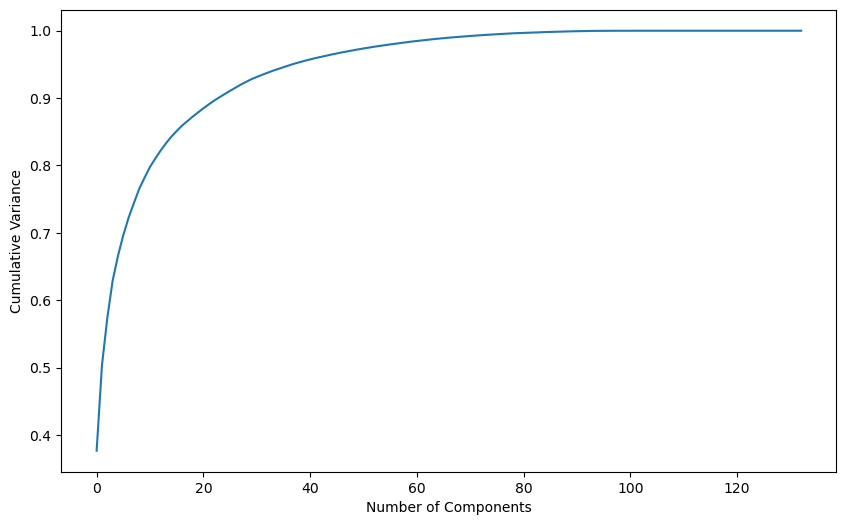

In [30]:
fig = plt.figure(figsize = (10,6))
plt.plot(variance_cumu)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
from sklearn.feature_selection import RFE

In [53]:
n_features_optimal=40

lm=LogisticRegression()
lm.fit(X_train,y_train)

rfe=RFE(lm,n_features_to_select=n_features_optimal)
rfe=rfe.fit(X_train,y_train)

y_pred=lm.predict(X_test)

In [34]:
test = pd.read_csv("test.csv.zip",encoding=('ISO-8859-1'),low_memory=False)
test.head()

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,...,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
0,69999,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,91.882,65.330,...,0,0,0,NaN,NaN,NaN,1692,0.00,0.00,0.00
1,70000,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,414.168,515.568,...,0,0,0,NaN,NaN,NaN,2533,0.00,0.00,0.00
2,70001,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,329.844,434.884,...,0,0,0,NaN,NaN,NaN,277,525.61,758.41,241.84
3,70002,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,43.550,171.390,...,0,0,0,NaN,NaN,NaN,1244,0.00,0.00,0.00
4,70003,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,306.854,406.289,...,0,0,0,NaN,NaN,NaN,462,0.00,0.00,0.00


In [35]:
test_missing_columns = (round(((test.isnull().sum()/len(test.index))*100),2).to_frame('null')).sort_values('null', ascending=False)
test_missing_columns

,null
arpu_3g_6,74.72
count_rech_3g_6,74.72
fb_user_6,74.72
night_pck_user_6,74.72
total_rech_data_6,74.72
...,...
last_day_rch_amt_8,0.00
vol_2g_mb_6,0.00
vol_2g_mb_7,0.00
vol_2g_mb_8,0.00


In [36]:
col_list_missing_50 = list(test_missing_columns.index[test_missing_columns['null'] > 50])

In [37]:
test = test.drop(col_list_missing_50, axis=1)

In [38]:
date_cols = [k for k in test.columns.to_list() if 'date' in k]
print(date_cols)

['last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8', 'date_of_last_rech_6', 'date_of_last_rech_7', 'date_of_last_rech_8']


In [39]:
test = test.drop(date_cols, axis=1)

In [40]:
test = test.drop('circle_id', axis=1)

In [41]:
test_missing_columns = (round(((test.isnull().sum()/len(test.index))*100),2).to_frame('null')).sort_values('null', ascending=False)
test_missing_columns

,null
loc_ic_t2f_mou_8,5.58
loc_og_t2f_mou_8,5.58
std_og_mou_8,5.58
loc_og_t2t_mou_8,5.58
std_ic_t2m_mou_8,5.58
...,...
max_rech_amt_6,0.00
max_rech_amt_7,0.00
max_rech_amt_8,0.00
last_day_rch_amt_6,0.00


In [42]:
test=test.fillna(value=0)

In [43]:
test = test.drop('id', axis=1)

In [44]:
test_missing_columns = (round(((test.isnull().sum()/len(test.index))*100),2).to_frame('null')).sort_values('null', ascending=False)
test_missing_columns

,null
loc_og_t2o_mou,0.0
std_ic_mou_6,0.0
ic_others_8,0.0
ic_others_7,0.0
ic_others_6,0.0
...,...
std_og_t2f_mou_6,0.0
std_og_t2m_mou_8,0.0
std_og_t2m_mou_7,0.0
std_og_t2m_mou_6,0.0


In [45]:
t=(test-np.min(test))/(np.max(test)-np.min(test)).values

In [46]:
t

,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,...,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
0,NaN,NaN,NaN,0.024858,0.136458,0.015477,0.004576,0.002730,0.003437,0.008641,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.376400,0.000000,0.000000,0.000000
1,NaN,NaN,NaN,0.053789,0.166005,0.037188,0.010874,0.005561,0.002951,0.068128,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.585761,0.000000,0.000000,0.000000
2,NaN,NaN,NaN,0.046219,0.160710,0.065415,0.001086,0.001061,0.001249,0.002439,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.024147,0.086815,0.094862,0.036562
3,NaN,NaN,NaN,0.020520,0.143419,0.012544,0.000765,0.000291,0.000000,0.005751,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.264874,0.000000,0.000000,0.000000
4,NaN,NaN,NaN,0.044155,0.158834,0.041031,0.064935,0.082179,0.104209,0.008753,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.070202,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,NaN,NaN,NaN,0.081140,0.158175,0.040505,0.046723,0.033735,0.042448,0.027341,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.267613,0.000613,0.013214,0.009295
29996,NaN,NaN,NaN,0.036209,0.153438,0.038222,0.037986,0.063047,0.096710,0.015588,...,0.0,0.083333,0.0,0.000000,0.000000,0.0,0.517301,0.000000,0.000000,0.000000
29997,NaN,NaN,NaN,0.029130,0.134680,0.023955,0.001596,0.002009,0.002966,0.005349,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.064725,0.000000,0.000000,0.000000
29998,NaN,NaN,NaN,0.117410,0.183432,0.029613,0.017675,0.006778,0.003935,0.266298,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.156833,0.000000,0.000000,0.000000


In [47]:
t=t.fillna(value=0)

In [48]:
t

,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,...,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
0,0.0,0.0,0.0,0.024858,0.136458,0.015477,0.004576,0.002730,0.003437,0.008641,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.376400,0.000000,0.000000,0.000000
1,0.0,0.0,0.0,0.053789,0.166005,0.037188,0.010874,0.005561,0.002951,0.068128,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.585761,0.000000,0.000000,0.000000
2,0.0,0.0,0.0,0.046219,0.160710,0.065415,0.001086,0.001061,0.001249,0.002439,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.024147,0.086815,0.094862,0.036562
3,0.0,0.0,0.0,0.020520,0.143419,0.012544,0.000765,0.000291,0.000000,0.005751,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.264874,0.000000,0.000000,0.000000
4,0.0,0.0,0.0,0.044155,0.158834,0.041031,0.064935,0.082179,0.104209,0.008753,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.070202,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,0.0,0.0,0.0,0.081140,0.158175,0.040505,0.046723,0.033735,0.042448,0.027341,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.267613,0.000613,0.013214,0.009295
29996,0.0,0.0,0.0,0.036209,0.153438,0.038222,0.037986,0.063047,0.096710,0.015588,...,0.0,0.083333,0.0,0.000000,0.000000,0.0,0.517301,0.000000,0.000000,0.000000
29997,0.0,0.0,0.0,0.029130,0.134680,0.023955,0.001596,0.002009,0.002966,0.005349,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.064725,0.000000,0.000000,0.000000
29998,0.0,0.0,0.0,0.117410,0.183432,0.029613,0.017675,0.006778,0.003935,0.266298,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.156833,0.000000,0.000000,0.000000


In [49]:
y_pred_lr=lm.predict(t)

In [50]:
y_pred_lr

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)